# 02 — ANÁLISIS PARA EL PAPER (sin entrenamiento)

Este notebook NO entrena modelos. Todos los resultados se generan a partir
de checkpoints previamente calculados.

Fuente de los resultados: Version15.ipynb (notebook de entrenamiento,
intacto, no se modifica ni se vuelve a ejecutar). Este notebook solo carga
los checkpoints (.pkl + .keras) generados por Version15.ipynb y recalcula
tablas, figuras y análisis de residuales a partir de ellos — sin llamar en
ningún momento a model.fit(), entrenar_modelo() ni entrenar_multisemilla().

## Alcance de este notebook
Carga los 3 checkpoints existentes: v15_mse, v15_huber015, v15_huber015_lr.

Reconstruye únicamente las fechas (dfs_merged) desde Datos_Embalses_Merged.xlsx — no repite la limpieza/imputación/merge de Version15.ipynb (Fase 1), que ya está congelada en ese archivo.

Verifica automáticamente que las métricas recalculadas coinciden con las métricas almacenadas en los checkpoints, antes de generar ninguna tabla o figura.

Reproduce, sin reentrenar: selección de configuración de pérdida (Wilcoxon + Holm-Bonferroni), tabla resumen final de test, comparación MLP vs. LSTM, ensemble por mediana, curvas de entrenamiento, predicciones vs. reales, análisis de residuales (incl. Ljung-Box) y el pronóstico iterativo de 30 días ya existente.

No modifica arquitecturas, hiperparámetros, semillas, partición train/val/test, funciones de pérdida, tratamiento de precipitación, tratamiento de ΔVolumen ni criterios estadísticos.

## Importaciones

In [3]:
# Celda 4 - Importaciones (subconjunto necesario para análisis — sin utilidades de entrenamiento)

import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, wilcoxon, norm

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import tensorflow as tf  # solo se usa para tf.keras.models.load_model (inferencia, no entrenamiento)

## Rutas de Archivos (idénticas a Version15.ipynb)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Celda 7 - RUTAS — apuntan exactamente a donde Version15.ipynb guardó los checkpoints

RUTA_BASE    = '/content/drive/MyDrive/Embalses/'
RUTA_DATOS   = RUTA_BASE + 'Datos_base/'
RUTA_FIGURAS = RUTA_BASE + 'Figuras/'

RUTA_CHECKPOINTS = RUTA_FIGURAS + 'checkpoints/'
RUTA_MODELOS     = RUTA_CHECKPOINTS + 'models/'

print('RUTA_CHECKPOINTS:', RUTA_CHECKPOINTS)
print('RUTA_MODELOS    :', RUTA_MODELOS)

RUTA_CHECKPOINTS: /content/drive/MyDrive/Embalses/Figuras/checkpoints/
RUTA_MODELOS    : /content/drive/MyDrive/Embalses/Figuras/checkpoints/models/


## 1. Reconstrucción liviana de `dfs_merged` (solo fechas)

No se repite la Fase 1 de `Version15.ipynb` (lectura de Excel crudos, limpieza,
imputación, merge, ADF/KPSS). Esa etapa ya está congelada en
`Datos_Embalses_Merged.xlsx`. Aquí solo se relee ese archivo para recuperar el
índice `Fecha` de cada embalse (necesario para el eje temporal de las figuras
y para las fechas reales del pronóstico), tal como ya estaba documentado en un
comentario de `Version15.ipynb` (Celda 12).


In [6]:
# Celda 9 - Reconstrucción liviana de dfs_merged desde el Excel ya fusionado (sin reprocesar nada)

dfs_merged = {}
for embalse, hoja in [('Sisga', 'Sisga'), ('Neusa', 'Neusa'), ('Tominé', 'Tomine')]:
    df = pd.read_excel(RUTA_DATOS + 'Datos_Embalses_Merged.xlsx', sheet_name=hoja)
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    dfs_merged[embalse] = df.set_index('Fecha')

for embalse, df in dfs_merged.items():
    print(f"{embalse:8s} — n={len(df)} | rango: {df.index.min().date()} → {df.index.max().date()}")

Sisga    — n=6940 | rango: 2006-01-01 → 2024-12-31
Neusa    — n=6940 | rango: 2006-01-01 → 2024-12-31
Tominé   — n=6940 | rango: 2006-01-01 → 2024-12-31


## 2. Carga de checkpoints (sin reentrenar)

`cargar_completo()` es exactamente la misma función definida en
`Version15.ipynb` (Celda 18): relee el `.pkl` liviano de cada configuración y
reinyecta el modelo `.keras` real correspondiente a cada semilla. No se
invoca en ningún momento `guardar_completo()` ni `entrenar_multisemilla()`.

In [8]:
# Celda 11

def cargar_completo(nombre_config: str) -> dict:
    """Recarga el pickle ligero e inyecta los modelos Keras reales.
    Copia idéntica de la función definida en Version15.ipynb (Celda 18).
    No entrena nada: solo lee archivos ya generados.
    """
    with open(f'{RUTA_CHECKPOINTS}/{nombre_config}.pkl', 'rb') as f:
        resultados = pickle.load(f)
    for embalse, modelos in resultados.items():
        for arq, corridas in modelos.items():
            for r in corridas:
                ruta_modelo = f'{RUTA_MODELOS}/{nombre_config}__{embalse}__{arq}__seed{r["seed"]}.keras'
                r['model'] = tf.keras.models.load_model(ruta_modelo)
    return resultados

In [9]:
# Celda 12
# Carga de las 3 configuraciones ya entrenadas — no llamadas a entrenar_modelo/entrenar_multisemilla

print("Cargando checkpoints existentes (sin reentrenar)...")

resultados_multi          = cargar_completo('v15_mse')
resultados_multi_huber    = cargar_completo('v15_huber015')
resultados_multi_huber_lr = cargar_completo('v15_huber015_lr')

CONFIGS = {
    'mse':      resultados_multi,
    'huber':    resultados_multi_huber,
    'huber_lr': resultados_multi_huber_lr,
}

n_modelos_cargados = sum(
    len(corridas)
    for config in CONFIGS.values()
    for modelos in config.values()
    for corridas in modelos.values()
)
print(f"Checkpoints cargados: {list(CONFIGS.keys())}")
print(f"Total de modelos .keras reinyectados: {n_modelos_cargados}")

Cargando checkpoints existentes (sin reentrenar)...
Checkpoints cargados: ['mse', 'huber', 'huber_lr']
Total de modelos .keras reinyectados: 180


## 3. Verificación automática: métricas recalculadas vs. métricas almacenadas

Dos capas de verificación, ninguna modifica ni reentrena nada:

1. **Consistencia interna del pickle** — para las 180 corridas (3 configs ×
   3 embalses × 2 arquitecturas × 10 semillas), se recalculan MAE/RMSE/MAPE/R²
   con `sklearn.metrics` a partir de `pred`/`y_real` ya almacenados, y se
   comparan con los valores guardados (`np.isclose`).
2. **Spot-check de inferencia** — para una muestra (la primera semilla de cada
   combinación embalse×arquitectura×config, 18 de 180), se vuelve a correr
   `model.predict(X_test)` sobre el `.keras` cargado, se reconstruye el
   volumen exactamente como en `_bloque()` (Version15, Celda 17), y se
   compara con la predicción almacenada. Esto confirma que el `.keras`
   coincide con lo que generó el `.pkl` — es inferencia, no entrenamiento.

In [11]:
# Celda 14
# Capa 1 — Consistencia interna del pickle (recalcular métricas desde pred/y_real ya guardados)

def verificar_metricas_almacenadas(configs: dict, atol: float = 1e-6) -> pd.DataFrame:
    filas = []
    for nombre_config, resultados in configs.items():
        for embalse, modelos in resultados.items():
            for arq, corridas in modelos.items():
                for r in corridas:
                    for split in ('val', 'test'):
                        bloque = r[split]
                        y_real = bloque['y_real']
                        pred   = bloque['pred']

                        mae_recalc  = mean_absolute_error(y_real, pred)
                        rmse_recalc = np.sqrt(mean_squared_error(y_real, pred))
                        r2_recalc   = r2_score(y_real, pred)

                        ok_mae  = np.isclose(mae_recalc,  bloque['mae'],  atol=atol)
                        ok_rmse = np.isclose(rmse_recalc, bloque['rmse'], atol=atol)
                        ok_r2   = np.isclose(r2_recalc,   bloque['r2'],   atol=atol)

                        filas.append({
                            'config': nombre_config, 'embalse': embalse, 'arquitectura': arq,
                            'seed': r['seed'], 'split': split,
                            'MAE OK': bool(ok_mae), 'RMSE OK': bool(ok_rmse), 'R2 OK': bool(ok_r2),
                        })
    return pd.DataFrame(filas)


df_verificacion_metricas = verificar_metricas_almacenadas(CONFIGS)

n_total  = len(df_verificacion_metricas)
n_ok     = int((df_verificacion_metricas[['MAE OK', 'RMSE OK', 'R2 OK']].all(axis=1)).sum())
n_fallos = n_total - n_ok

print(f"Verificación de consistencia interna (pred/y_real almacenados vs. métricas almacenadas)")
print(f"Filas verificadas (config x embalse x arq x semilla x split): {n_total}")
print(f"  OK    : {n_ok}")
print(f"  FALLOS: {n_fallos}")

if n_fallos > 0:
    print("\n¡ATENCIÓN! Filas con discrepancia (revisar antes de continuar):")
    print(df_verificacion_metricas[~df_verificacion_metricas[['MAE OK', 'RMSE OK', 'R2 OK']].all(axis=1)])
else:
    print("\nTodas las métricas recalculadas coinciden con las almacenadas en los checkpoints. ✓")

Verificación de consistencia interna (pred/y_real almacenados vs. métricas almacenadas)
Filas verificadas (config x embalse x arq x semilla x split): 360
  OK    : 360
  FALLOS: 0

Todas las métricas recalculadas coinciden con las almacenadas en los checkpoints. ✓


In [12]:
# Celda 15
# Capa 2 — Spot-check de inferencia (recorre model.predict en una muestra, sin reentrenar)

def verificar_inferencia_muestra(configs: dict, atol: float = 1e-4) -> pd.DataFrame:
    """Para la primera semilla de cada (config, embalse, arquitectura), vuelve a
    correr model.predict(X_test) y reconstruye el volumen exactamente como
    _bloque() en Version15 (Celda 17), comparando contra lo almacenado.
    Es inferencia sobre un modelo ya entrenado — no hay fit() en ningún punto.
    """
    filas = []
    for nombre_config, resultados in configs.items():
        for embalse, modelos in resultados.items():
            for arq, corridas in modelos.items():
                r = corridas[0]  # primera semilla de esta combinación

                model      = r['model']
                scaler_vol = r['scaler_vol']
                X_test     = r['X_test']
                vol_t_minus_1 = r['test']['vol_t_minus_1']

                pred_delta_scaled = model.predict(X_test, verbose=0)
                pred_delta = scaler_vol.inverse_transform(pred_delta_scaled).flatten()
                pred_recalc = (vol_t_minus_1 + pred_delta).reshape(-1, 1)

                pred_almacenado = r['test']['pred']
                coincide = np.allclose(pred_recalc, pred_almacenado, atol=atol)

                mae_recalc = mean_absolute_error(r['test']['y_real'], pred_recalc)

                filas.append({
                    'config': nombre_config, 'embalse': embalse, 'arquitectura': arq,
                    'seed': r['seed'],
                    'MAE almacenado': r['test']['mae'], 'MAE recalculado (predict)': mae_recalc,
                    'Predicciones idénticas': bool(coincide),
                })
    return pd.DataFrame(filas)


df_verificacion_inferencia = verificar_inferencia_muestra(CONFIGS)
print("Spot-check de inferencia (model.predict sobre .keras cargado, muestra de "
      f"{len(df_verificacion_inferencia)}/{n_modelos_cargados} corridas)")
print(df_verificacion_inferencia.round(6).to_string(index=False))

if df_verificacion_inferencia['Predicciones idénticas'].all():
    print("\nTodas las predicciones recalculadas coinciden con las almacenadas. ✓")
else:
    print("\n¡ATENCIÓN! Alguna corrida no coincide — revisar antes de continuar.")

Spot-check de inferencia (model.predict sobre .keras cargado, muestra de 18/180 corridas)
  config embalse arquitectura  seed  MAE almacenado  MAE recalculado (predict)  Predicciones idénticas
     mse   Sisga          MLP    42        0.124208                   0.124208                    True
     mse   Sisga         LSTM    42        0.097195                   0.097195                    True
     mse   Neusa          MLP    42        0.083591                   0.083591                    True
     mse   Neusa         LSTM    42        0.071455                   0.071455                    True
     mse  Tominé          MLP    42        0.349854                   0.349854                    True
     mse  Tominé         LSTM    42        0.314561                   0.314560                    True
   huber   Sisga          MLP    42        0.119537                   0.119537                    True
   huber   Sisga         LSTM    42        0.097082                   0.097082        

## 4. Selección de configuración de pérdida (Wilcoxon + Holm-Bonferroni)

Copia idéntica de la lógica de `Version15.ipynb` (Celdas 24-25). Criterio:
MAE en validación, Wilcoxon pareado (N=10), Holm-Bonferroni **dentro de cada
combinación embalse×arquitectura** (m=2 candidatos vs. baseline MSE). El test
set no participa en esta decisión.

In [13]:
# Celda 17
# Holm-Bonferroni — copia idéntica de Version15.ipynb (Celda 24)

def holm_bonferroni(pvalues: list, alpha: float = 0.05):
    """Devuelve (p_ajustados, rechazos) usando el método de Holm-Bonferroni."""
    pvalues = np.asarray(pvalues, dtype=float)
    m = len(pvalues)
    orden = np.argsort(pvalues)
    ajustados = np.empty(m)
    p_prev = 0.0
    for rank, idx in enumerate(orden):
        ajustado = min((m - rank) * pvalues[idx], 1.0)
        ajustado = max(ajustado, p_prev)
        ajustados[idx] = ajustado
        p_prev = ajustado
    rechazos = ajustados < alpha
    return ajustados, rechazos

In [14]:
# Celda 18
# Selección de configuración — copia idéntica de Version15.ipynb (Celda 25)

def _mae_val_por_semilla(corridas: list) -> np.ndarray:
    return np.array([r['val']['mae'] for r in corridas])


def seleccionar_configuracion(configs: dict, dfs: dict,
                               baseline: str = 'mse',
                               alpha: float = 0.05) -> tuple:
    embalses      = list(dfs.keys())
    arquitecturas = list(next(iter(configs.values()))[embalses[0]].keys())
    candidatos    = [c for c in configs if c != baseline]

    seleccion      = {}
    filas_detalle  = []

    for embalse in embalses:
        seleccion[embalse] = {}
        for arq in arquitecturas:
            maes = {nombre: _mae_val_por_semilla(configs[nombre][embalse][arq])
                    for nombre in configs}

            p_raw = []
            for c in candidatos:
                try:
                    _, p = wilcoxon(maes[c], maes[baseline])
                except ValueError:
                    p = np.nan
                p_raw.append(p)

            p_validos = [p if not np.isnan(p) else 1.0 for p in p_raw]
            p_adj, rechazos = holm_bonferroni(p_validos, alpha=alpha)

            for c, p_r, p_a, rech in zip(candidatos, p_raw, p_adj, rechazos):
                filas_detalle.append({
                    'Embalse': embalse, 'Arquitectura': arq, 'Config': c,
                    'MAE val candidato (media)': np.mean(maes[c]),
                    'MAE val MSE (media)':       np.mean(maes[baseline]),
                    'Δ MAE (candidato − MSE)':   np.mean(maes[c]) - np.mean(maes[baseline]),
                    'p crudo (vs MSE)':          p_r,
                    'p ajustado (Holm)':         p_a,
                    'Significativo (α=0.05)':    bool(rech),
                    'Candidato mejora a MSE':    bool(rech and np.mean(maes[c]) < np.mean(maes[baseline])),
                })

            ganador   = baseline
            mejor_mae = np.mean(maes[baseline])
            for c, p_a, rech in zip(candidatos, p_adj, rechazos):
                mae_c = np.mean(maes[c])
                if rech and mae_c < mejor_mae:
                    ganador, mejor_mae = c, mae_c

            seleccion[embalse][arq] = {
                'config_ganadora': ganador,
                'corridas':        configs[ganador][embalse][arq],
                'mae_val_medio':   mejor_mae,
            }

    df_detalle = pd.DataFrame(filas_detalle)
    return seleccion, df_detalle


seleccion, df_seleccion_detalle = seleccionar_configuracion(CONFIGS, dfs_merged, baseline='mse')

print("DETALLE DE LA SELECCIÓN DE CONFIGURACIÓN")
print("Criterio: MAE en VALIDACIÓN (Mm³) — Wilcoxon pareado N=10, Holm-Bonferroni")
print("=" * 100)
print(df_seleccion_detalle.round(4).to_string(index=False))

print("\nCONFIGURACIÓN GANADORA POR EMBALSE Y ARQUITECTURA")
for embalse, por_arq in seleccion.items():
    for arq, info in por_arq.items():
        print(f"  {embalse:8s} | {arq:5s} -> {info['config_ganadora']:9s} "
              f"(MAE val medio = {info['mae_val_medio']:.4f} Mm³)")

DETALLE DE LA SELECCIÓN DE CONFIGURACIÓN
Criterio: MAE en VALIDACIÓN (Mm³) — Wilcoxon pareado N=10, Holm-Bonferroni
Embalse Arquitectura   Config  MAE val candidato (media)  MAE val MSE (media)  Δ MAE (candidato − MSE)  p crudo (vs MSE)  p ajustado (Holm)  Significativo (α=0.05)  Candidato mejora a MSE
  Sisga          MLP    huber                     0.0916               0.0971                  -0.0056            0.0039             0.0039                    True                    True
  Sisga          MLP huber_lr                     0.0874               0.0971                  -0.0098            0.0020             0.0039                    True                    True
  Sisga         LSTM    huber                     0.0793               0.0808                  -0.0016            0.1309             0.1309                   False                   False
  Sisga         LSTM huber_lr                     0.0769               0.0808                  -0.0039            0.0020            

## 5. Tabla resumen final (test) — copia idéntica de Version15.ipynb (Celda 26)

In [15]:
# Celda 20
def construir_tabla_resumen(seleccion: dict) -> pd.DataFrame:
    filas = []
    for embalse, por_arq in seleccion.items():
        for arq, info in por_arq.items():
            corridas  = info['corridas']
            maes      = np.array([r['test']['mae']  for r in corridas])
            rmses     = np.array([r['test']['rmse'] for r in corridas])
            mapes     = np.array([r['test']['mape'] for r in corridas])
            mae_naive = corridas[0]['test']['mae_naive']
            skills    = maes / mae_naive

            try:
                stat, p_vs_naive = wilcoxon(maes - mae_naive)
            except ValueError:
                stat, p_vs_naive = np.nan, np.nan

            filas.append({
                'Embalse': embalse, 'Arquitectura': arq,
                'Config ganadora':   info['config_ganadora'],
                'N semillas':        len(corridas),
                'MAE (media±DE)':    f"{maes.mean():.3f} ± {maes.std():.3f}",
                'RMSE (media±DE)':   f"{rmses.mean():.3f} ± {rmses.std():.3f}",
                'MAPE % (media±DE)': f"{mapes.mean():.2f} ± {mapes.std():.2f}",
                'MAE Naive (deriva)': f"{mae_naive:.3f}",
                'Skill (media±DE)':  f"{skills.mean():.4f} ± {skills.std():.4f}",
                'Wilcoxon stat (vs Naive)': f"{stat:.3f}" if not np.isnan(stat) else "N/A",
                'Wilcoxon p (vs Naive)':    f"{p_vs_naive:.4f}" if not np.isnan(p_vs_naive) else "N/A",
                'Conclusión vs Naive': ('Supera al Naive ✓'
                                        if (not np.isnan(p_vs_naive) and p_vs_naive < 0.05
                                            and skills.mean() < 1)
                                        else 'No se diferencia / no supera al Naive'),
            })
    return pd.DataFrame(filas)


df_resumen_final = construir_tabla_resumen(seleccion)
print("TABLA RESUMEN FINAL — TEST (N=10 semillas por configuración ganadora)")
print("=" * 100)
print(df_resumen_final.to_string(index=False))

TABLA RESUMEN FINAL — TEST (N=10 semillas por configuración ganadora)
Embalse Arquitectura Config ganadora  N semillas MAE (media±DE) RMSE (media±DE) MAPE % (media±DE) MAE Naive (deriva) Skill (media±DE) Wilcoxon stat (vs Naive) Wilcoxon p (vs Naive)                   Conclusión vs Naive
  Sisga          MLP        huber_lr          10  0.109 ± 0.003   0.206 ± 0.004       0.18 ± 0.00              0.106  1.0317 ± 0.0270                    1.000                0.0039 No se diferencia / no supera al Naive
  Sisga         LSTM        huber_lr          10  0.093 ± 0.001   0.194 ± 0.000       0.15 ± 0.00              0.106  0.8784 ± 0.0053                    0.000                0.0020                     Supera al Naive ✓
  Neusa          MLP        huber_lr          10  0.080 ± 0.002   0.134 ± 0.004       0.09 ± 0.00              0.075  1.0700 ± 0.0256                    0.000                0.0020 No se diferencia / no supera al Naive
  Neusa         LSTM             mse          10  0.07

## 6. Comparación entre arquitecturas (MLP vs. LSTM) — copia idéntica de Version15.ipynb (Celda 27)

In [16]:
# Celda 22
def comparar_arquitecturas(seleccion: dict, alpha: float = 0.05) -> tuple:
    filas    = []
    p_raw    = []
    embalses = list(seleccion.keys())

    for embalse in embalses:
        maes_mlp  = np.array([r['test']['mae'] for r in seleccion[embalse]['MLP']['corridas']])
        maes_lstm = np.array([r['test']['mae'] for r in seleccion[embalse]['LSTM']['corridas']])
        try:
            stat, p = wilcoxon(maes_mlp, maes_lstm)
        except ValueError:
            stat, p = np.nan, np.nan
        p_raw.append(p if not np.isnan(p) else 1.0)
        filas.append({'Embalse': embalse,
                      'MAE MLP (media)':  maes_mlp.mean(),
                      'MAE LSTM (media)': maes_lstm.mean(),
                      'Wilcoxon stat': stat, 'p crudo': p})

    p_adj, rechazos = holm_bonferroni(p_raw, alpha=alpha)
    mejor_por_embalse = {}
    for fila, p_a, rech in zip(filas, p_adj, rechazos):
        fila['p ajustado (Holm)'] = p_a
        if rech:
            ganador = 'MLP' if fila['MAE MLP (media)'] < fila['MAE LSTM (media)'] else 'LSTM'
        else:
            ganador = 'Empate (p≥0.05)'
        fila['Ganador'] = ganador
        mejor_por_embalse[fila['Embalse']] = (ganador if ganador != 'Empate (p≥0.05)'
                                               else ('MLP' if fila['MAE MLP (media)'] < fila['MAE LSTM (media)']
                                                     else 'LSTM'))

    return pd.DataFrame(filas), mejor_por_embalse


df_arquitecturas, mejor_por_embalse = comparar_arquitecturas(seleccion)

print("COMPARACIÓN MLP vs LSTM (cada una en su configuración ganadora) — TEST, N=10, Holm-Bonferroni")
print("=" * 95)
print(df_arquitecturas.round(4).to_string(index=False))
print()
for embalse, ganador in mejor_por_embalse.items():
    empató = (df_arquitecturas.loc[df_arquitecturas['Embalse'] == embalse, 'Ganador'].iloc[0]
              == 'Empate (p≥0.05)')
    etiqueta = (f"{ganador} (sin diferencia estadísticamente significativa frente al otro)"
                if empató else ganador)
    print(f"  {embalse}: mejor modelo -> {etiqueta}")

COMPARACIÓN MLP vs LSTM (cada una en su configuración ganadora) — TEST, N=10, Holm-Bonferroni
Embalse  MAE MLP (media)  MAE LSTM (media)  Wilcoxon stat  p crudo  p ajustado (Holm) Ganador
  Sisga           0.1094            0.0932            0.0   0.0020             0.0059    LSTM
  Neusa           0.0803            0.0728            0.0   0.0020             0.0059    LSTM
 Tominé           0.3408            0.3196            3.0   0.0098             0.0098    LSTM

  Sisga: mejor modelo -> LSTM
  Neusa: mejor modelo -> LSTM
  Tominé: mejor modelo -> LSTM


## 7. Ensemble por mediana — copia idéntica de Version15.ipynb (Celda 28)

In [17]:
# Celda 24

def construir_ensemble(corridas: list, metodo: str = 'mediana') -> dict:
    pred_deltas     = np.stack([r['test']['pred_delta'] for r in corridas])
    pred_delta_ens  = (np.median(pred_deltas, axis=0) if metodo == 'mediana'
                       else pred_deltas.mean(axis=0))

    ref            = corridas[0]['test']
    vol_t_minus_1  = ref['vol_t_minus_1']
    y_real_delta   = ref['y_real_delta']
    naive_delta    = ref['naive_delta']
    mae_naive, rmse_naive, mape_naive = ref['mae_naive'], ref['rmse_naive'], ref['mape_naive']

    pred_vol_ens   = (vol_t_minus_1 + pred_delta_ens).reshape(-1, 1)
    y_real_vol     = (vol_t_minus_1 + y_real_delta).reshape(-1, 1)
    pred_naive_vol = (vol_t_minus_1 + naive_delta).reshape(-1, 1)

    mae  = mean_absolute_error(y_real_vol, pred_vol_ens)
    rmse = np.sqrt(mean_squared_error(y_real_vol, pred_vol_ens))
    mape = np.mean(np.abs((y_real_vol - pred_vol_ens) / y_real_vol)) * 100
    r2   = r2_score(y_real_vol, pred_vol_ens)
    residuales = (y_real_vol - pred_vol_ens).flatten()

    return {
        'y_real': y_real_vol, 'pred': pred_vol_ens, 'pred_naive': pred_naive_vol,
        'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2,
        'mae_naive': mae_naive, 'rmse_naive': rmse_naive, 'mape_naive': mape_naive,
        'residuales': residuales,
        'seed': f"ensemble {metodo} (N={len(corridas)})",
        'metodo': metodo, 'n_semillas': len(corridas),
    }


corridas_ganadoras = {}
corridas_finales   = {}
for embalse in dfs_merged.keys():
    corridas_ganadoras[embalse] = {}
    corridas_finales[embalse]   = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        corridas_ganadoras[embalse][arq] = corridas
        corridas_finales[embalse][arq]   = construir_ensemble(corridas, metodo='mediana')

print("ENSEMBLE POR MEDIANA — configuración ganadora por embalse/arquitectura")
print("=" * 78)
filas_ens = []
for embalse in dfs_merged.keys():
    for arq in ['MLP', 'LSTM']:
        ens  = corridas_finales[embalse][arq]
        maes = [r['test']['mae'] for r in corridas_ganadoras[embalse][arq]]
        skill_ensemble = ens['mae'] / ens['mae_naive']
        filas_ens.append({
            'Embalse': embalse, 'Arquitectura': arq,
            'Config': seleccion[embalse][arq]['config_ganadora'],
            'MAE individual (media)':    np.mean(maes),
            'MAE ensemble (mediana)':    ens['mae'],
            'RMSE ensemble (mediana)':   ens['rmse'],
            'Skill ensemble (mediana)':  skill_ensemble,
            '¿Supera al Naive? (ensemble)': 'Sí ✓' if skill_ensemble < 1 else 'No ✗',
            '¿Mediana mejora al promedio individual?': 'Sí' if ens['mae'] < np.mean(maes) else 'No',
        })
df_ensemble = pd.DataFrame(filas_ens)
print(df_ensemble.round(4).to_string(index=False))

ENSEMBLE POR MEDIANA — configuración ganadora por embalse/arquitectura
Embalse Arquitectura   Config  MAE individual (media)  MAE ensemble (mediana)  RMSE ensemble (mediana)  Skill ensemble (mediana) ¿Supera al Naive? (ensemble) ¿Mediana mejora al promedio individual?
  Sisga          MLP huber_lr                  0.1094                  0.0991                   0.1969                    0.9344                         Sí ✓                                      Sí
  Sisga         LSTM huber_lr                  0.0932                  0.0929                   0.1935                    0.8754                         Sí ✓                                      Sí
  Neusa          MLP huber_lr                  0.0803                  0.0757                   0.1281                    1.0090                         No ✗                                      Sí
  Neusa         LSTM      mse                  0.0728                  0.0719                   0.1229                    0.9579         

## 8. Figuras — reproducción idéntica (sin cambios de formato todavía)

Las siguientes figuras se generan con el mismo código de `Version15.ipynb`
(Celdas 29-33), a partir de los datos ya cargados. El formateo para estándares
de revista se hará en un paso posterior, aprobado por separado.

### 8.1 Curvas de entrenamiento (loss / val_loss)

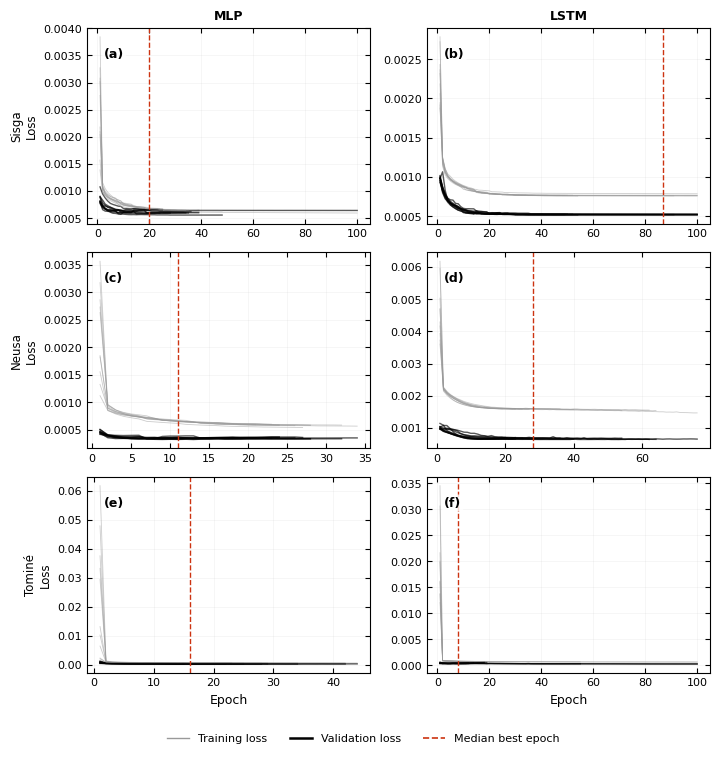

Figura 1 guardada en: /content/drive/MyDrive/Embalses/Figuras_Paper/


In [18]:
# Celda 27

import os
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_TRAIN = '#999999'
COLOR_VAL   = '#000000'
COLOR_REF   = '#CC3311'
LW_TRAIN, ALPHA_TRAIN = 0.6, 0.50
LW_VAL,   ALPHA_VAL   = 1.0, 0.65

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']
n_embalses     = len(embalses_orden)

fig, axes = plt.subplots(n_embalses, 2, figsize=(7.2, 7.5))
axes = np.atleast_2d(axes)

panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    for col, arq in enumerate(arquitecturas):
        corridas = corridas_ganadoras[embalse][arq]
        ax = axes[fila, col]

        mejores_epocas = []
        for r in corridas:
            hist = r['history'].history if hasattr(r['history'], 'history') else r['history']
            ep = np.arange(1, len(hist['loss']) + 1)
            ax.plot(ep, hist['loss'],     color=COLOR_TRAIN, linewidth=LW_TRAIN, alpha=ALPHA_TRAIN)
            ax.plot(ep, hist['val_loss'], color=COLOR_VAL,   linewidth=LW_VAL,   alpha=ALPHA_VAL)
            mejores_epocas.append(int(np.argmin(hist['val_loss'])) + 1)

        mediana_ep = int(np.median(mejores_epocas))
        ax.axvline(mediana_ep, color=COLOR_REF, linestyle='--', linewidth=1.0)

        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(alpha=0.15, linewidth=0.5)

        ax.text(0.06, 0.90, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=9, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
        i_letra += 1

        if fila == 0:
            ax.set_title(arq, fontsize=9, fontweight='bold', pad=6)
        ax.set_ylabel(f'{embalse}\nLoss' if col == 0 else '', fontsize=8.5)
        if fila == n_embalses - 1:
            ax.set_xlabel('Epoch')

handles = [
    Line2D([0], [0], color=COLOR_TRAIN, lw=1.0, label='Training loss'),
    Line2D([0], [0], color=COLOR_VAL,   lw=1.8, label='Validation loss'),
    Line2D([0], [0], color=COLOR_REF,   lw=1.2, linestyle='--', label='Median best epoch'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.035, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure1_LossCurves.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure1_LossCurves.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura 1 guardada en:", RUTA_FIGURAS_PAPER)

### 8.2 Predicciones vs. valores reales (test)

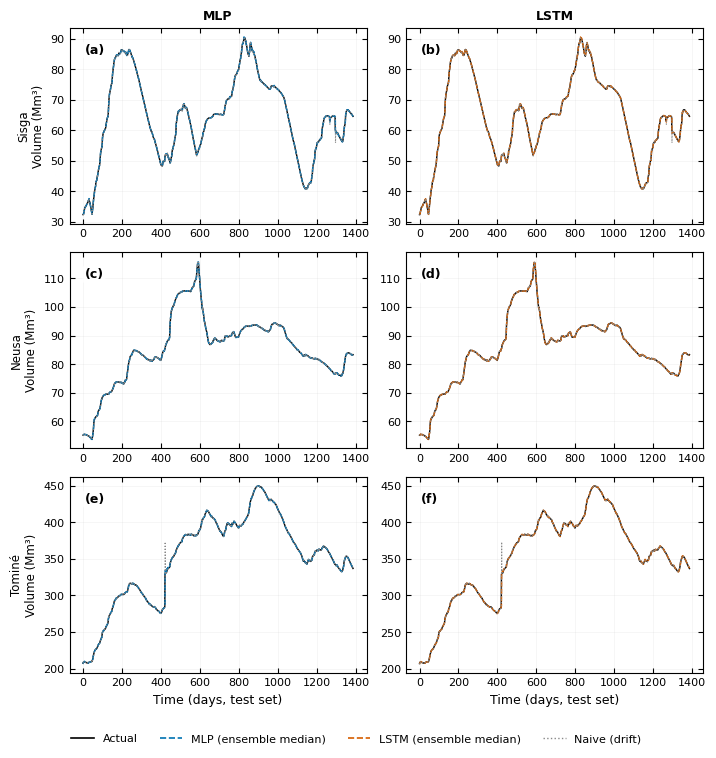

Figura S1 guardada en: /content/drive/MyDrive/Embalses/Figuras_Paper/


In [19]:
# Celda 29

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_ACTUAL = '#000000'
COLOR_NAIVE  = '#888888'
COLOR_MLP    = '#0072B2'
COLOR_LSTM   = '#D55E00'
COLOR_ARCH   = {'MLP': COLOR_MLP, 'LSTM': COLOR_LSTM}

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']

fig, axes = plt.subplots(len(embalses_orden), 2, figsize=(7.2, 7.5))
axes = np.atleast_2d(axes)

panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    for col, arq in enumerate(arquitecturas):
        info = corridas_finales[embalse][arq]
        ax = axes[fila, col]

        y_r = info['y_real'].flatten()
        y_p = info['pred'].flatten()
        y_n = info['pred_naive'].flatten()

        ax.plot(y_r, color=COLOR_ACTUAL,    linewidth=1.0)
        ax.plot(y_p, color=COLOR_ARCH[arq], linewidth=1.0, linestyle='--')
        ax.plot(y_n, color=COLOR_NAIVE,     linewidth=0.8, linestyle=':')

        ax.text(0.05, 0.92, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=9, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
        i_letra += 1

        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(alpha=0.15, linewidth=0.5)

        if fila == 0:
            ax.set_title(arq, fontsize=9, fontweight='bold', pad=6)
        ax.set_ylabel(f'{embalse}\nVolume (Mm\u00b3)' if col == 0 else '', fontsize=8.5)
        if fila == len(embalses_orden) - 1:
            ax.set_xlabel('Time (days, test set)')

handles = [
    Line2D([0], [0], color=COLOR_ACTUAL, lw=1.2, label='Actual'),
    Line2D([0], [0], color=COLOR_MLP,    lw=1.2, linestyle='--', label='MLP (ensemble median)'),
    Line2D([0], [0], color=COLOR_LSTM,   lw=1.2, linestyle='--', label='LSTM (ensemble median)'),
    Line2D([0], [0], color=COLOR_NAIVE,  lw=1.0, linestyle=':',  label='Naive (drift)'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.035, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/FigureS1_Predictions_MLP_LSTM.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/FigureS1_Predictions_MLP_LSTM.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura S1 guardada en:", RUTA_FIGURAS_PAPER)

### 8.3 Mejor modelo por embalse (figura combinada)

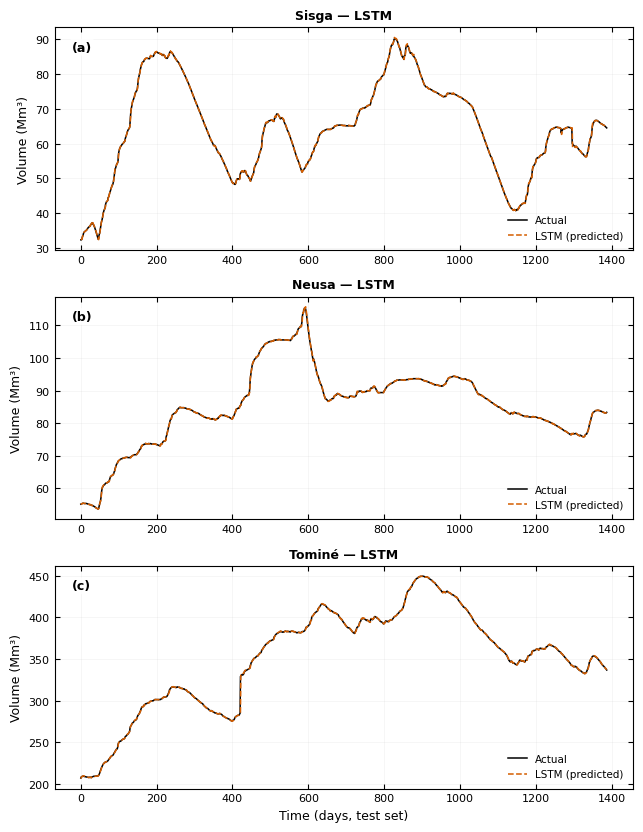

Figura 3 guardada en: /content/drive/MyDrive/Embalses/Figuras_Paper/


In [20]:
# Celda 31

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_ACTUAL = '#000000'
COLOR_MLP    = '#0072B2'
COLOR_LSTM   = '#D55E00'
COLOR_ARCH   = {'MLP': COLOR_MLP, 'LSTM': COLOR_LSTM}

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
panel_letras = ['(a)', '(b)', '(c)']

fig, axes = plt.subplots(len(embalses_orden), 1, figsize=(6.5, 8.4))
axes = np.atleast_1d(axes)

for i, (ax, embalse) in enumerate(zip(axes, embalses_orden)):
    ganador = mejor_por_embalse[embalse]
    info    = corridas_finales[embalse][ganador]
    color   = COLOR_ARCH[ganador]

    y_r = info['y_real'].flatten()
    y_p = info['pred'].flatten()

    ax.plot(y_r, color=COLOR_ACTUAL, linewidth=1.1, label='Actual')
    ax.plot(y_p, color=color, linewidth=1.1, linestyle='--', label=f'{ganador} (predicted)')

    ax.text(0.03, 0.94, panel_letras[i], transform=ax.transAxes,
             fontsize=9, fontweight='bold', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))

    ax.tick_params(direction='in', top=True, right=True)
    ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_title(f'{embalse} \u2014 {ganador}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Volume (Mm\u00b3)')
    if i == len(embalses_orden) - 1:
        ax.set_xlabel('Time (days, test set)')

    ax.legend(loc='lower right', frameon=False, fontsize=7.5, handlelength=1.8)

plt.tight_layout()

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure3_BestModel.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure3_BestModel.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura 3 guardada en:", RUTA_FIGURAS_PAPER)

### 8.4 Análisis de residuales

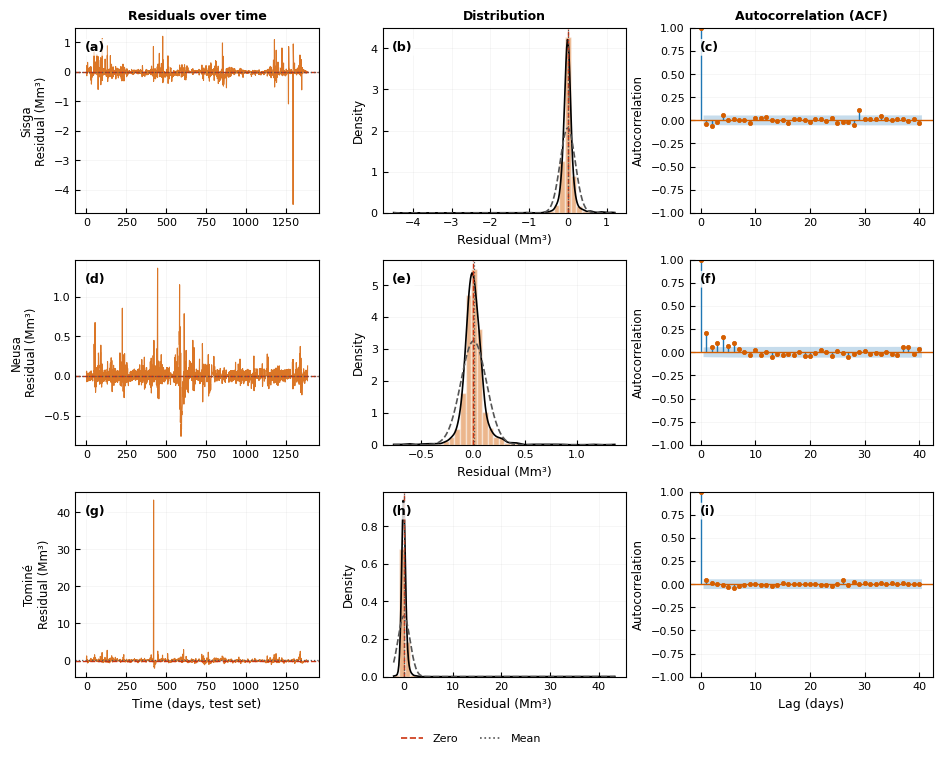

Figura 4 guardada en: /content/drive/MyDrive/Embalses/Figuras_Paper/


In [21]:
# Celda 33

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_MLP  = '#0072B2'
COLOR_LSTM = '#D55E00'
COLOR_ARCH = {'MLP': COLOR_MLP, 'LSTM': COLOR_LSTM}
COLOR_REF  = '#CC3311'
COLOR_MEAN = '#555555'

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
columnas = ['Residuals over time', 'Distribution', 'Autocorrelation (ACF)']

lb_resultados = {}

fig, axes = plt.subplots(len(embalses_orden), 3, figsize=(9.5, 7.5))
axes = np.atleast_2d(axes)

letras = [f'({chr(ord("a")+k)})' for k in range(len(embalses_orden) * 3)]
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    ganador    = mejor_por_embalse[embalse]
    info       = corridas_finales[embalse][ganador]
    color      = COLOR_ARCH[ganador]
    residuales = info['residuales']
    n_res      = len(residuales)
    media_res  = float(np.mean(residuales))
    std_res    = float(np.std(residuales))
    pct_neg    = float(np.mean(residuales < 0) * 100)

    # Columna 0 — serie temporal
    ax = axes[fila, 0]
    ax.plot(residuales, color=color, linewidth=0.8, alpha=0.85)
    ax.axhline(0, color=COLOR_REF, linestyle='--', linewidth=1.0)
    ax.axhline(media_res, color=COLOR_MEAN, linestyle=':', linewidth=0.9)
    ax.text(0.04, 0.93, letras[i_letra], transform=ax.transAxes, fontsize=9, fontweight='bold',
             va='top', ha='left', bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
    i_letra += 1
    ax.tick_params(direction='in'); ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_ylabel(f'{embalse}\nResidual (Mm\u00b3)', fontsize=8.5)
    if fila == len(embalses_orden) - 1:
        ax.set_xlabel('Time (days, test set)')
    if fila == 0:
        ax.set_title(columnas[0], fontsize=9, fontweight='bold', pad=6)

    # Columna 1 — histograma + KDE + normal
    ax = axes[fila, 1]
    ax.hist(residuales, bins=40, color=color, alpha=0.45, edgecolor='white', density=True)
    eje_x = np.linspace(residuales.min(), residuales.max(), 300)
    kde   = gaussian_kde(residuales)
    ax.plot(eje_x, kde(eje_x), color='black', linewidth=1.2)
    ax.plot(eje_x, norm.pdf(eje_x, loc=media_res, scale=std_res), color=COLOR_MEAN, linewidth=1.2, linestyle='--')
    ax.axvline(0, color=COLOR_REF, linestyle='--', linewidth=1.0)
    ax.axvline(media_res, color=COLOR_MEAN, linestyle=':', linewidth=0.9)
    ax.text(0.04, 0.93, letras[i_letra], transform=ax.transAxes, fontsize=9, fontweight='bold',
             va='top', ha='left', bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
    i_letra += 1
    ax.tick_params(direction='in'); ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_ylabel('Density', fontsize=8.5)
    ax.set_xlabel('Residual (Mm\u00b3)')
    if fila == 0:
        ax.set_title(columnas[1], fontsize=9, fontweight='bold', pad=6)

    # Columna 2 — ACF
    ax = axes[fila, 2]
    plot_acf(residuales, lags=min(40, n_res // 4), ax=ax, color=color, title='')

    for ln in ax.lines:
      ln.set_markersize(3)
      ln.set_markeredgewidth(0.6)

    ax.text(0.04, 0.93, letras[i_letra], transform=ax.transAxes, fontsize=9, fontweight='bold',
             va='top', ha='left', bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
    i_letra += 1
    ax.tick_params(direction='in'); ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_ylabel('Autocorrelation', fontsize=8.5)
    if fila == len(embalses_orden) - 1:
        ax.set_xlabel('Lag (days)')
    if fila == 0:
        ax.set_title(columnas[2], fontsize=9, fontweight='bold', pad=6)

    lb = acorr_ljungbox(residuales, lags=[10, 20, 30], return_df=True)
    lb_resultados[embalse] = {
        'modelo': ganador, 'config': seleccion[embalse][ganador]['config_ganadora'],
        'info': info, 'media': media_res, 'std': std_res, 'pct_neg': pct_neg, 'lb': lb,
    }

handles = [
    Line2D([0], [0], color=COLOR_REF,  lw=1.2, linestyle='--', label='Zero'),
    Line2D([0], [0], color=COLOR_MEAN, lw=1.2, linestyle=':',  label='Mean'),
]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure4_Residuals.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure4_Residuals.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura 4 guardada en:", RUTA_FIGURAS_PAPER)

### 8.5 Resultados numéricos de residuales y Ljung-Box

In [22]:
# Celda 35

print("\n" + "=" * 70)
print("RESULTADOS NUMÉRICOS: RESIDUALES (VOLUMEN RECONSTRUIDO) Y TEST DE LJUNG-BOX")
print("=" * 70)

for embalse, res in lb_resultados.items():
    info  = res['info']
    skill = info['mae'] / info['mae_naive']
    print(f"\n{'─'*65}")
    print(f"Embalse : {embalse}   |   Modelo : {res['modelo']}   |   Config : {res['config']}")
    print(f"{'─'*65}")
    print(f"  MAE                  : {info['mae']:.4f} Mm³")
    print(f"  RMSE                 : {info['rmse']:.4f} Mm³")
    print(f"  MAPE                 : {info['mape']:.4f} %")
    print(f"  R²                   : {info['r2']:.6f}")
    print(f"  MAE naive (deriva)   : {info['mae_naive']:.4f} Mm³")
    print(f"  Skill ratio          : {skill:.4f}  "
          f"({'modelo mejora al naive ✓' if skill < 1 else 'modelo NO mejora al naive ✗'})")

    bias_ok = abs(res['media']) < info['mae'] * 0.05
    pct_ok  = abs(res['pct_neg'] - 50) < 10
    print(f"\n  Media residuales     : {res['media']:.4f} Mm³  "
          f"({'≈ 0, sin sesgo ✓' if bias_ok else 'SESGO DETECTADO ✗'})")
    print(f"  Desv. estándar       : {res['std']:.4f} Mm³")
    print(f"  % residuales < 0     : {res['pct_neg']:.1f}%  "
          f"({'≈ 50%, sin sesgo direccional ✓' if pct_ok else 'SESGO DIRECCIONAL ✗ (esperado ~50%)'})")

    print(f"\n  Ljung-Box — residuales (volumen reconstruido):")
    for idx, row in res['lb'].iterrows():
        marca = ("<- Rechaza H0 (autocorr. significativa)  ✗"
                 if row['lb_pvalue'] < 0.05 else "<- No rechaza H0  ✓")
        print(f"    Lag {int(idx):2d}:  Q={row['lb_stat']:7.3f}  p={row['lb_pvalue']:.4f}  {marca}")

print("\n" + "=" * 70)
print("FIN DEL ANÁLISIS NUMÉRICO — reproducido íntegramente desde checkpoints")
print("=" * 70)


RESULTADOS NUMÉRICOS: RESIDUALES (VOLUMEN RECONSTRUIDO) Y TEST DE LJUNG-BOX

─────────────────────────────────────────────────────────────────
Embalse : Sisga   |   Modelo : LSTM   |   Config : huber_lr
─────────────────────────────────────────────────────────────────
  MAE                  : 0.0929 Mm³
  RMSE                 : 0.1935 Mm³
  MAPE                 : 0.1535 %
  R²                   : 0.999794
  MAE naive (deriva)   : 0.1061 Mm³
  Skill ratio          : 0.8754  (modelo mejora al naive ✓)

  Media residuales     : -0.0044 Mm³  (≈ 0, sin sesgo ✓)
  Desv. estándar       : 0.1934 Mm³
  % residuales < 0     : 54.4%  (≈ 50%, sin sesgo direccional ✓)

  Ljung-Box — residuales (volumen reconstruido):
    Lag 10:  Q= 15.146  p=0.1268  <- No rechaza H0  ✓
    Lag 20:  Q= 19.788  p=0.4713  <- No rechaza H0  ✓
    Lag 30:  Q= 44.617  p=0.0419  <- Rechaza H0 (autocorr. significativa)  ✗

─────────────────────────────────────────────────────────────────
Embalse : Neusa   |   Modelo : LS

## 9. Pronóstico multi-step iterativo — Escenario A (automático)

Copia idéntica de Version15.ipynb (Celdas 34-37). El punto de arranque se elige automáticamente por máxima variación conjunta observada en el propio test set. El Escenario B (evento/fecha específica) se trata por separado en la Sección 10; ambos escenarios se preservan y se comparan en la Sección 10.4.

### 9.1 Selección del punto de arranque (máxima variación conjunta)

In [24]:
# Celda 38

ref_embalses = {
    embalse: seleccion[embalse]['MLP']['corridas'][0]['test']
    for embalse in dfs_merged.keys()
}

horizonte  = 30
n_test     = len(list(ref_embalses.values())[0]['y_real'])
variaciones = []

for idx in range(n_test - horizonte):
    var_total = 0
    for embalse, ref in ref_embalses.items():
        y = ref['y_real'].flatten()[idx:idx + horizonte]
        v = ref['vol_t_minus_1'][idx]
        var_total += np.std(y - v)
    variaciones.append((idx, var_total))

top5 = sorted(variaciones, key=lambda x: x[1], reverse=True)[:5]
print("Top 5 puntos de arranque por variación conjunta:")
for idx, var in top5:
    print(f"  idx={idx:4d}  variación conjunta={var:.3f}")
    for embalse, ref in ref_embalses.items():
        y = ref['y_real'].flatten()[idx:idx + horizonte]
        v = ref['vol_t_minus_1'][idx]
        print(f"    {embalse}: arranque={v:.2f}  día30={y[-1]:.2f}  "
              f"Δtotal={y[-1]-v:.2f}  "
              f"MAE_naive={mean_absolute_error(y, np.full(30, v)):.3f}")

IDX_ARRANQUE       = top5[0][0]
HORIZONTE_FORECAST = 30
print(f"\nÍndice de arranque seleccionado automáticamente: idx={IDX_ARRANQUE}")

Top 5 puntos de arranque por variación conjunta:
  idx= 405  variación conjunta=28.180
    Sisga: arranque=48.59  día30=52.12  Δtotal=3.53  MAE_naive=2.092
    Neusa: arranque=82.36  día30=88.12  Δtotal=5.76  MAE_naive=3.171
    Tominé: arranque=277.27  día30=335.65  Δtotal=58.38  MAE_naive=27.890
  idx= 406  variación conjunta=28.162
    Sisga: arranque=48.40  día30=51.83  Δtotal=3.43  MAE_naive=2.356
    Neusa: arranque=82.63  día30=88.21  Δtotal=5.58  MAE_naive=3.091
    Tominé: arranque=277.74  día30=335.92  Δtotal=58.18  MAE_naive=29.357
  idx= 407  variación conjunta=28.046
    Sisga: arranque=48.30  día30=51.48  Δtotal=3.18  MAE_naive=2.544
    Neusa: arranque=83.08  día30=88.30  Δtotal=5.23  MAE_naive=2.820
    Tominé: arranque=279.17  día30=336.19  Δtotal=57.03  MAE_naive=29.835
  idx= 404  variación conjunta=28.046
    Sisga: arranque=48.68  día30=52.27  Δtotal=3.59  MAE_naive=1.911
    Neusa: arranque=82.19  día30=88.03  Δtotal=5.84  MAE_naive=3.157
    Tominé: arranque=276.

### 9.2 Funciones de pronóstico iterativo (individual y ensemble)

In [25]:
# Celda 40

def forecast_iterativo_individual(r: dict, idx: int, horizonte: int = 30) -> np.ndarray:
    """Pronóstico multi-step iterativo para UNA semilla (bivariado).
    Copia idéntica de Version15.ipynb (Celda 35). Usa el modelo ya entrenado
    (r['model']) solo para inferencia (model.predict), no para reentrenar.
    """
    model       = r['model']
    scaler_vol  = r['scaler_vol']
    scaler_prec = r['scaler_prec']
    formato_3d  = r['formato_3d']
    ventana     = r['ventana']

    ventana_actual = r['X_test'][idx].copy()
    vol_actual = float(r['test']['vol_t_minus_1'][idx])
    preds_vol  = []

    for h in range(horizonte):
        if formato_3d:
            entrada = ventana_actual.reshape(1, ventana, 2)
        else:
            entrada = ventana_actual.reshape(1, ventana * 2)

        delta_scaled = model.predict(entrada, verbose=0)
        delta        = float(scaler_vol.inverse_transform(delta_scaled)[0, 0])
        vol_actual  += delta
        preds_vol.append(vol_actual)

        nuevo_dvol = float(delta_scaled[0, 0])

        idx_siguiente = idx + h + 1
        if idx_siguiente < len(r['X_test']):
            if formato_3d:
                nuevo_prec = float(r['X_test'][idx_siguiente][-1, 1])
            else:
                nuevo_prec = float(r['X_test'][idx_siguiente][ventana - 1 + ventana])
                nuevo_prec = float(r['X_test'][idx_siguiente][2 * ventana - 1])
        else:
            if formato_3d:
                nuevo_prec = float(ventana_actual[-1, 1])
            else:
                nuevo_prec = float(ventana_actual[2 * ventana - 1])

        if formato_3d:
            ventana_actual = np.roll(ventana_actual, -1, axis=0)
            ventana_actual[-1, 0] = nuevo_dvol
            ventana_actual[-1, 1] = nuevo_prec
        else:
            ventana_actual = np.roll(ventana_actual, -1)
            ventana_actual[ventana - 1]     = nuevo_dvol
            ventana_actual[2 * ventana - 1] = nuevo_prec

    return np.array(preds_vol)


def forecast_iterativo_ensemble(corridas: list, idx: int,
                                     horizonte: int = 30,
                                     metodo: str = 'mediana') -> dict:
    trayectorias = np.stack([
        forecast_iterativo_individual(r, idx, horizonte) for r in corridas
    ])

    pred_vol_ens = (np.median(trayectorias, axis=0) if metodo == 'mediana'
                    else trayectorias.mean(axis=0))

    ref          = corridas[0]['test']
    y_real       = ref['y_real'].flatten()[idx:idx + horizonte]
    vol_arranque = float(ref['vol_t_minus_1'][idx])
    naive        = np.full(horizonte, vol_arranque)

    mae_modelo      = mean_absolute_error(y_real, pred_vol_ens)
    mae_naive_plano = mean_absolute_error(y_real, naive)
    skill = mae_modelo / mae_naive_plano if mae_naive_plano > 0 else np.nan

    return {
        'horizonte': horizonte, 'n_semillas': len(corridas),
        'pred_vol':             pred_vol_ens,
        'trayectorias':         trayectorias,
        'y_real_horizonte':     y_real,
        'pred_naive_horizonte': naive,
        'vol_arranque':         vol_arranque,
        'mae':                  mae_modelo,
        'mae_naive_plano':      mae_naive_plano,
        'skill':                skill,
    }

### 9.3 Ejecución del pronóstico — Escenario A

In [26]:
# Celda 42

print(f"\nPRONÓSTICO MULTI-STEP ITERATIVO (30 días) — idx={IDX_ARRANQUE}, "
      f"máxima variación conjunta")
print("=" * 70)

forecasts = {}
for embalse in dfs_merged.keys():
    forecasts[embalse] = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        fc = forecast_iterativo_ensemble(
            corridas, idx=IDX_ARRANQUE, horizonte=HORIZONTE_FORECAST
        )
        forecasts[embalse][arq] = fc
        print(f"{embalse:8s} — {arq:4s} (N={fc['n_semillas']}): "
              f"MAE={fc['mae']:.3f}  |  "
              f"Naive plano={fc['mae_naive_plano']:.3f}  |  "
              f"Skill={fc['skill']:.4f} "
              f"({'mejora ✓' if fc['skill'] < 1 else 'no mejora ✗'})")


PRONÓSTICO MULTI-STEP ITERATIVO (30 días) — idx=405, máxima variación conjunta
Sisga    — MLP  (N=10): MAE=6.212  |  Naive plano=2.092  |  Skill=2.9692 (no mejora ✗)
Sisga    — LSTM (N=10): MAE=0.554  |  Naive plano=2.092  |  Skill=0.2650 (mejora ✓)
Neusa    — MLP  (N=10): MAE=8.196  |  Naive plano=3.171  |  Skill=2.5844 (no mejora ✗)
Neusa    — LSTM (N=10): MAE=1.243  |  Naive plano=3.171  |  Skill=0.3921 (mejora ✓)
Tominé   — MLP  (N=10): MAE=136.036  |  Naive plano=27.890  |  Skill=4.8776 (no mejora ✗)
Tominé   — LSTM (N=10): MAE=25.072  |  Naive plano=27.890  |  Skill=0.8989 (mejora ✓)


### 9.4 Figura — Escenario A (30 días)

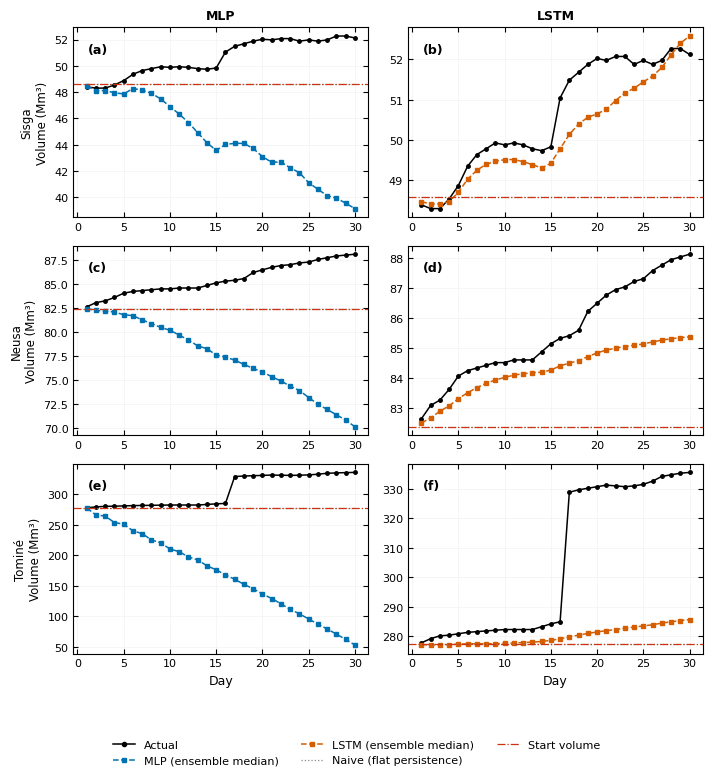

Figura 5 guardada en: /content/drive/MyDrive/Embalses/Figuras_Paper/


In [29]:
# Celda 44

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

COLOR_ACTUAL = '#000000'
COLOR_NAIVE  = '#888888'
COLOR_MLP    = '#0072B2'
COLOR_LSTM   = '#D55E00'
COLOR_ARCH   = {'MLP': COLOR_MLP, 'LSTM': COLOR_LSTM}
COLOR_REF    = '#CC3311'

RUTA_FIGURAS_PAPER = RUTA_BASE + 'Figuras_Paper/'
os.makedirs(RUTA_FIGURAS_PAPER + 'pdf/', exist_ok=True)
os.makedirs(RUTA_FIGURAS_PAPER + 'png/', exist_ok=True)

embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']
panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

fig, axes = plt.subplots(len(embalses_orden), 2, figsize=(7.2, 7.5))
axes = np.atleast_2d(axes)

i_letra = 0
dias = np.arange(1, HORIZONTE_FORECAST + 1)

for fila, embalse in enumerate(embalses_orden):
    for col, arq in enumerate(arquitecturas):
        fc = forecasts[embalse][arq]
        color = COLOR_ARCH[arq]
        ax = axes[fila, col]

        ax.plot(dias, fc['y_real_horizonte'], color=COLOR_ACTUAL, linewidth=1.1, marker='o', markersize=2.5)
        ax.plot(dias, fc['pred_vol'], color=color, linewidth=1.1, linestyle='--', marker='s', markersize=2.5)
        ax.plot(dias, fc['pred_naive_horizonte'], color=COLOR_NAIVE, linewidth=0.9, linestyle=':')
        ax.axhline(fc['vol_arranque'], color=COLOR_REF, linestyle='-.', linewidth=0.9)

        ax.text(0.05, 0.92, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=9, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8))
        i_letra += 1

        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(alpha=0.15, linewidth=0.5)

        if fila == 0:
            ax.set_title(arq, fontsize=9, fontweight='bold', pad=6)
        ax.set_ylabel(f'{embalse}\nVolume (Mm\u00b3)' if col == 0 else '', fontsize=8.5)
        if fila == len(embalses_orden) - 1:
            ax.set_xlabel('Day')

handles = [
    Line2D([0], [0], color=COLOR_ACTUAL, lw=1.1, marker='o', markersize=3, label='Actual'),
    Line2D([0], [0], color=COLOR_MLP,    lw=1.1, linestyle='--', marker='s', markersize=3, label='MLP (ensemble median)'),
    Line2D([0], [0], color=COLOR_LSTM,   lw=1.1, linestyle='--', marker='s', markersize=3, label='LSTM (ensemble median)'),
    Line2D([0], [0], color=COLOR_NAIVE,  lw=0.9, linestyle=':',  label='Naive (flat persistence)'),
    Line2D([0], [0], color=COLOR_REF,    lw=0.9, linestyle='-.', label='Start volume'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure5_Forecast30d.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure5_Forecast30d.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura 5 guardada en:", RUTA_FIGURAS_PAPER)

### 9.5 Fechas reales del pronóstico — Escenario A

In [30]:
# Celda 46

# Fechas empleadas en el pronóstico anterior (usa dfs_merged reconstruido en la sección 1)
for embalse in dfs_merged.keys():
    ref = seleccion[embalse]['MLP']['corridas'][0]
    n_train_val = ref['val_size'] + ref['ventana']
    idx_absoluto = n_train_val + IDX_ARRANQUE
    fecha     = dfs_merged[embalse].index[idx_absoluto]
    fecha_fin = dfs_merged[embalse].index[idx_absoluto + 29]
    print(f"{embalse}: {fecha.date()} → {fecha_fin.date()}")

Sisga: 2022-04-23 → 2022-05-22
Neusa: 2022-04-23 → 2022-05-22
Tominé: 2022-04-23 → 2022-05-22


## 10. Pronóstico multi-step iterativo — Escenario B (evento/fecha específica)

Mapeo reproducible de una fecha real a los índices de test, con las 5 validaciones requeridas (existencia, rango permitido, ventana previa de 30 días, horizonte disponible, no leakage). No reemplaza el Escenario A — ambos se preservan y se comparan en la Sección 10.4.

### 10.1 Mapeo de fecha a índices de test (con validaciones)

In [32]:
# Celda 48

def _obtener_split_referencia(embalse: str) -> dict:
    """Extrae val_size/ventana de las corridas reales de `embalse` y
    verifica que sean consistentes entre arquitecturas y semillas
    (no se asume, se comprueba)."""
    valores = set()
    for arq in ['MLP', 'LSTM']:
        for r in seleccion[embalse][arq]['corridas']:
            valores.add((r['val_size'], r['ventana']))
    if len(valores) != 1:
        raise ValueError(
            f"[{embalse}] val_size/ventana NO son consistentes entre "
            f"arquitecturas/semillas: {valores}. Revisar antes de continuar."
        )
    val_size, ventana = valores.pop()
    return {'val_size': val_size, 'ventana': ventana,
            'idx_test_inicio': val_size + ventana}


def mapear_fecha_a_indices(fecha_arranque: str,
                            embalses: list = None,
                            horizonte: int = HORIZONTE_FORECAST) -> dict:
    """
    Mapea FECHA_ARRANQUE (día ancla = último dato real ANTES del pronóstico,
    misma convención que vol_arranque / test['vol_t_minus_1'][idx] en
    Escenario A) a los índices de test necesarios para
    forecast_iterativo_individual/_ensemble.

    Aplica las 5 validaciones:
      1) la fecha existe en la serie
      2) está dentro del periodo de test permitido
      3) hay ventana de 30 días previa disponible (garantizado si idx_test>=0,
         por construcción de X_test)
      4) el horizonte de 30 días está disponible para evaluación
      5) no hay leakage (aserción cruzada de fechas + consistencia entre
         los tres embalses)

    Si cualquiera falla para cualquier embalse, lanza ValueError con mensaje
    explícito — no ejecuta un escenario parcial o silenciosamente incorrecto.
    """
    if embalses is None:
        embalses = list(dfs_merged.keys())

    try:
        fecha_ts = pd.Timestamp(fecha_arranque)
    except Exception as e:
        raise ValueError(f"FECHA_ARRANQUE='{fecha_arranque}' no es una fecha válida: {e}")

    resultado = {}
    idx_test_global = None

    for embalse in embalses:
        idx_serie_full = dfs_merged[embalse].index

        # (1) La fecha existe en la serie
        if fecha_ts < idx_serie_full.min() or fecha_ts > idx_serie_full.max():
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} está fuera del "
                f"rango de la serie ({idx_serie_full.min().date()} → "
                f"{idx_serie_full.max().date()})."
            )
        if fecha_ts not in idx_serie_full:
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} no existe en el "
                f"índice de dfs_merged['{embalse}']. Verifica el formato de fecha."
            )
        idx_serie = idx_serie_full.get_loc(fecha_ts)

        split = _obtener_split_referencia(embalse)
        idx_test_inicio = split['idx_test_inicio']

        ref_test  = seleccion[embalse]['MLP']['corridas'][0]['test']
        ref_Xtest = seleccion[embalse]['MLP']['corridas'][0]['X_test']
        n_test = len(ref_Xtest)
        if n_test != len(ref_test['y_real']):
            raise ValueError(
                f"[{embalse}] Inconsistencia interna: len(X_test)={n_test} "
                f"!= len(test['y_real'])={len(ref_test['y_real'])}."
            )

        idx_test = idx_serie - idx_test_inicio

        # (2) Dentro del periodo permitido (test set)
        if idx_test < 0:
            fecha_min_test = idx_serie_full[idx_test_inicio]
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} cae en train/val, "
                f"no en test. La fecha ancla más temprana permitida es "
                f"{fecha_min_test.date()}."
            )
        if idx_test > n_test - 1:
            fecha_max_test = idx_serie_full[idx_test_inicio + n_test - 1]
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} está después del "
                f"final del test set. La fecha ancla más tardía permitida "
                f"(sin exigir aún horizonte completo) es {fecha_max_test.date()}."
            )

        # (4) Horizonte de 30 días disponible para evaluación
        if idx_test + horizonte > n_test:
            fecha_max_valida = idx_serie_full[idx_test_inicio + n_test - horizonte]
            raise ValueError(
                f"[{embalse}] FECHA_ARRANQUE={fecha_ts.date()} no tiene "
                f"{horizonte} días reales posteriores en el test set para evaluar. "
                f"La fecha ancla más tardía permitida con horizonte completo es "
                f"{fecha_max_valida.date()}."
            )

        # (3) Ventana previa de 30 días: garantizada por construcción de X_test
        #     (idx_test >= 0 ya lo asegura).

        # (5) No leakage: aserción de consistencia de fechas
        fecha_dia1  = idx_serie_full[idx_serie + 1]
        fecha_dia30 = idx_serie_full[idx_serie + horizonte]
        fecha_check = idx_serie_full[idx_test_inicio + idx_test]
        if fecha_check != fecha_ts:
            raise ValueError(
                f"[{embalse}] Inconsistencia al mapear idx_test de vuelta a la "
                f"serie: esperado {fecha_ts.date()}, obtenido {fecha_check.date()}. "
                f"Abortando — no se ejecuta el escenario."
            )

        if idx_test_global is None:
            idx_test_global = idx_test
        elif idx_test_global != idx_test:
            raise ValueError(
                f"[{embalse}] idx_test={idx_test} difiere del calculado para otro "
                f"embalse (idx_test_global={idx_test_global}). Los tres embalses "
                f"deberían compartir el mismo calendario — revisar."
            )

        resultado[embalse] = {
            'idx_test': idx_test,
            'fecha_arranque': fecha_ts,
            'fecha_dia1': fecha_dia1,
            'fecha_dia30': fecha_dia30,
        }

    return resultado

### 10.2 Ejecución del pronóstico — Escenario B

In [33]:
# Celda 50
# Escenario B — Evento/fecha específica

# Cambiar SOLO esta línea para generar un nuevo escenario:
FECHA_ARRANQUE = '2024-04-15'

mapeo_B = mapear_fecha_a_indices(FECHA_ARRANQUE, horizonte=HORIZONTE_FORECAST)

print(f"\nESCENARIO B — fecha de arranque: {FECHA_ARRANQUE}")
for embalse, info in mapeo_B.items():
    print(f"  {embalse:8s}: idx_test={info['idx_test']:4d}  "
          f"ancla={info['fecha_arranque'].date()}  "
          f"día1={info['fecha_dia1'].date()}  día30={info['fecha_dia30'].date()}")

forecasts_B = {}
for embalse in dfs_merged.keys():
    idx_test_B = mapeo_B[embalse]['idx_test']
    forecasts_B[embalse] = {}
    for arq in ['MLP', 'LSTM']:
        corridas = seleccion[embalse][arq]['corridas']
        fc = forecast_iterativo_ensemble(
            corridas, idx=idx_test_B, horizonte=HORIZONTE_FORECAST
        )
        forecasts_B[embalse][arq] = fc
        print(f"{embalse:8s} — {arq:4s} (N={fc['n_semillas']}): "
              f"MAE={fc['mae']:.3f}  |  Naive plano={fc['mae_naive_plano']:.3f}  |  "
              f"Skill={fc['skill']:.4f} ({'mejora ✓' if fc['skill'] < 1 else 'no mejora ✗'})")


ESCENARIO B — fecha de arranque: 2024-04-15
  Sisga   : idx_test=1128  ancla=2024-04-15  día1=2024-04-16  día30=2024-05-15
  Neusa   : idx_test=1128  ancla=2024-04-15  día1=2024-04-16  día30=2024-05-15
  Tominé  : idx_test=1128  ancla=2024-04-15  día1=2024-04-16  día30=2024-05-15
Sisga    — MLP  (N=10): MAE=6.468  |  Naive plano=1.725  |  Skill=3.7497 (no mejora ✗)
Sisga    — LSTM (N=10): MAE=0.567  |  Naive plano=1.725  |  Skill=0.3285 (mejora ✓)
Neusa    — MLP  (N=10): MAE=6.893  |  Naive plano=0.154  |  Skill=44.6560 (no mejora ✗)
Neusa    — LSTM (N=10): MAE=0.684  |  Naive plano=0.154  |  Skill=4.4334 (no mejora ✗)
Tominé   — MLP  (N=10): MAE=107.722  |  Naive plano=4.919  |  Skill=21.8984 (no mejora ✗)
Tominé   — LSTM (N=10): MAE=1.048  |  Naive plano=4.919  |  Skill=0.2131 (mejora ✓)


### 10.3 Función auxiliar de fechas para la tabla de validación

In [36]:
# Celda 52

# Validación del pronóstico (Escenario A y B, ambos preservados)

def fechas_escenario(embalse: str, idx_test: int, horizonte: int = HORIZONTE_FORECAST) -> dict:
    """Reconstruye fecha de arranque y fechas día 1..horizonte para un
    (embalse, idx_test) ya validado. Usa el mismo split que
    mapear_fecha_a_indices — no reintroduce lógica distinta."""
    idx_serie_full = dfs_merged[embalse].index
    split = _obtener_split_referencia(embalse)
    idx_serie = split['idx_test_inicio'] + idx_test
    fecha_arranque = idx_serie_full[idx_serie]
    fechas_dias = [idx_serie_full[idx_serie + h] for h in range(1, horizonte + 1)]
    return {'fecha_arranque': fecha_arranque, 'fechas_dias': fechas_dias}

### 10.4 Construcción y comparación de la tabla de validación (Escenario A vs. B)

In [37]:
# Celda 54

def construir_tabla_validacion(forecasts_dict: dict, idx_por_embalse: dict,
                                nombre_escenario: str,
                                horizonte: int = HORIZONTE_FORECAST) -> tuple:
    """
    idx_por_embalse: {embalse: idx_test}  (mismo idx_test usado para generar
    forecasts_dict, ya sea IDX_ARRANQUE (A, mismo valor los 3 embalses) o
    mapeo_B[embalse]['idx_test'] (B, por embalse)).
    Devuelve (tabla_detalle, tabla_resumen).
    """
    filas_detalle = []
    filas_resumen = []

    for embalse in forecasts_dict.keys():
        idx_test = idx_por_embalse[embalse]
        fch = fechas_escenario(embalse, idx_test, horizonte)

        for arq in ['MLP', 'LSTM']:
            fc = forecasts_dict[embalse][arq]

            rmse_modelo = float(np.sqrt(mean_squared_error(fc['y_real_horizonte'], fc['pred_vol'])))
            rmse_naive  = float(np.sqrt(mean_squared_error(fc['y_real_horizonte'], fc['pred_naive_horizonte'])))
            skill_rmse  = rmse_modelo / rmse_naive if rmse_naive > 0 else np.nan

            filas_resumen.append({
                'Escenario': nombre_escenario, 'Embalse': embalse, 'Arquitectura': arq,
                'Fecha inicio (ancla)': fch['fecha_arranque'].date(),
                'Volumen inicial (Mm3)': fc['vol_arranque'],
                'N semillas': fc['n_semillas'],
                'MAE': fc['mae'], 'RMSE': rmse_modelo, 'Skill (MAE)': fc['skill'],
                'MAE naive': fc['mae_naive_plano'], 'RMSE naive': rmse_naive,
                'Skill (RMSE)': skill_rmse,
            })

            for h in range(horizonte):
                filas_detalle.append({
                    'Escenario': nombre_escenario, 'Embalse': embalse, 'Arquitectura': arq,
                    'Fecha inicio (ancla)': fch['fecha_arranque'].date(),
                    'Volumen inicial (Mm3)': fc['vol_arranque'],
                    'Dia': h + 1, 'Fecha': fch['fechas_dias'][h].date(),
                    'Volumen real (Mm3)': float(fc['y_real_horizonte'][h]),
                    'Pronostico (Mm3)': float(fc['pred_vol'][h]),
                    'Naive persistencia (Mm3)': float(fc['pred_naive_horizonte'][h]),
                })

    return pd.DataFrame(filas_detalle), pd.DataFrame(filas_resumen)


# --- Escenario A: mismo IDX_ARRANQUE para los 3 embalses (Celda 36) ---
idx_A_por_embalse = {embalse: IDX_ARRANQUE for embalse in dfs_merged.keys()}
tabla_detalle_A, tabla_resumen_A = construir_tabla_validacion(
    forecasts, idx_A_por_embalse, nombre_escenario='A - Automatico (max. variacion)'
)

# --- Escenario B: idx_test por embalse desde mapeo_B ---
idx_B_por_embalse = {embalse: mapeo_B[embalse]['idx_test'] for embalse in dfs_merged.keys()}
tabla_detalle_B, tabla_resumen_B = construir_tabla_validacion(
    forecasts_B, idx_B_por_embalse, nombre_escenario=f'B - Evento ({FECHA_ARRANQUE})'
)

tabla_detalle_final = pd.concat([tabla_detalle_A, tabla_detalle_B], ignore_index=True)
tabla_resumen_final = pd.concat([tabla_resumen_A, tabla_resumen_B], ignore_index=True)

print("TABLA RESUMEN — Escenario A vs B")
print("=" * 100)
print(tabla_resumen_final.round(4).to_string(index=False))

TABLA RESUMEN — Escenario A vs B
                      Escenario Embalse Arquitectura Fecha inicio (ancla)  Volumen inicial (Mm3)  N semillas      MAE     RMSE  Skill (MAE)  MAE naive  RMSE naive  Skill (RMSE)
A - Automatico (max. variacion)   Sisga          MLP           2022-04-23                48.5866          10   6.2122   7.5272       2.9692     2.0922      2.4582        3.0620
A - Automatico (max. variacion)   Sisga         LSTM           2022-04-23                48.5866          10   0.5544   0.7019       0.2650     2.0922      2.4582        0.2855
A - Automatico (max. variacion)   Neusa          MLP           2022-04-23                82.3641          10   8.1961   9.7870       2.5844     3.1714      3.5495        2.7573
A - Automatico (max. variacion)   Neusa         LSTM           2022-04-23                82.3641          10   1.2434   1.4924       0.3921     3.1714      3.5495        0.4205
A - Automatico (max. variacion)  Tominé          MLP           2022-04-23         

### 10.5 Exportación de la validación (CSV + Excel)

In [38]:
# Celda 56

RUTA_RESULTADOS_PRONOSTICOS = RUTA_BASE + 'Resultados_Pronosticos/'
os.makedirs(RUTA_RESULTADOS_PRONOSTICOS, exist_ok=True)

tabla_detalle_final.to_csv(RUTA_RESULTADOS_PRONOSTICOS + 'forecast_validacion_detalle.csv', index=False)
tabla_resumen_final.to_csv(RUTA_RESULTADOS_PRONOSTICOS + 'forecast_validacion_resumen.csv', index=False)

with pd.ExcelWriter(RUTA_RESULTADOS_PRONOSTICOS + 'forecast_validacion.xlsx') as writer:
    tabla_resumen_final.to_excel(writer, sheet_name='Resumen', index=False)
    tabla_detalle_final.to_excel(writer, sheet_name='Detalle_diario', index=False)

print("Guardado en:", RUTA_RESULTADOS_PRONOSTICOS)

Guardado en: /content/drive/MyDrive/Embalses/Resultados_Pronosticos/


### 10.6 Figura — Escenario B (30 días, con fechas reales)

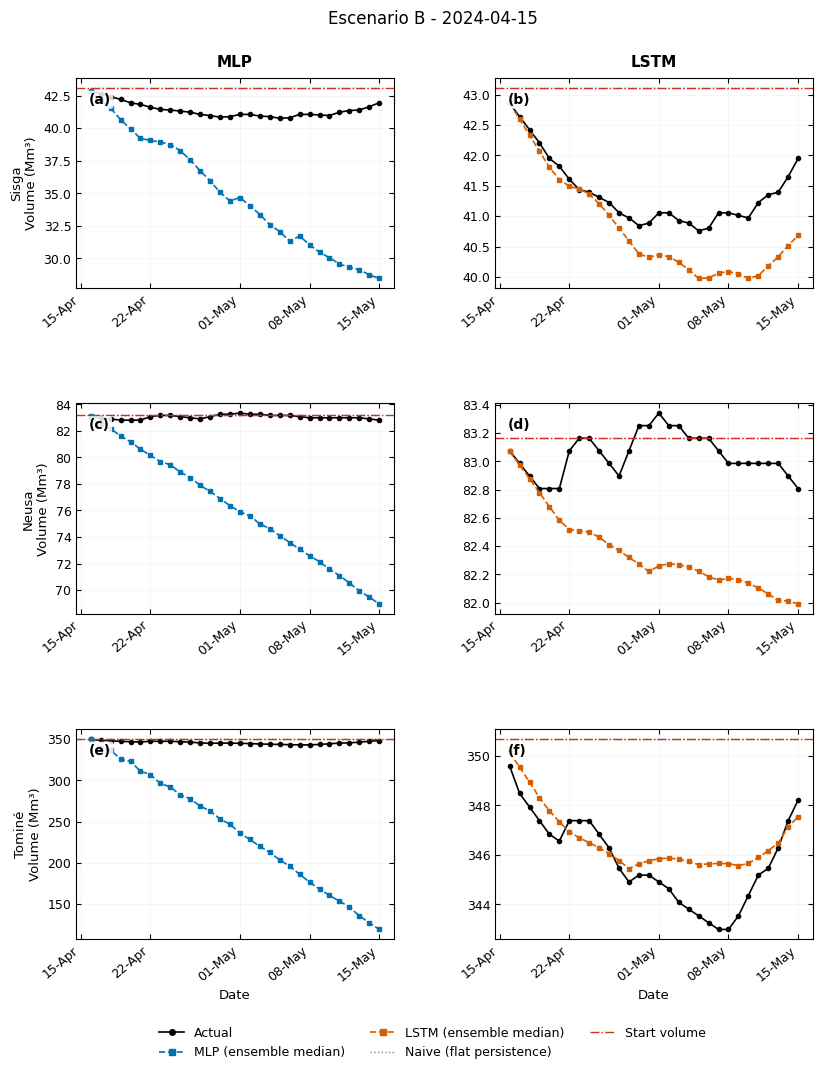

Figura Escenario B guardada en: /content/drive/MyDrive/Embalses/Figuras_Paper/


In [40]:
# Celda 58

import matplotlib.dates as mdates

embalses_orden = list(dfs_merged.keys())
arquitecturas  = ['MLP', 'LSTM']
panel_letras = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

fig, axes = plt.subplots(len(embalses_orden), 2, figsize=(9.5, 10.5))
axes = np.atleast_2d(axes)
i_letra = 0

for fila, embalse in enumerate(embalses_orden):
    idx_test_B = mapeo_B[embalse]['idx_test']
    fch = fechas_escenario(embalse, idx_test_B, HORIZONTE_FORECAST)
    fechas_x = fch['fechas_dias']

    for col, arq in enumerate(arquitecturas):
        fc = forecasts_B[embalse][arq]
        color = COLOR_ARCH[arq]
        ax = axes[fila, col]

        ax.plot(fechas_x, fc['y_real_horizonte'], color=COLOR_ACTUAL, linewidth=1.2, marker='o', markersize=3)
        ax.plot(fechas_x, fc['pred_vol'], color=color, linewidth=1.2, linestyle='--', marker='s', markersize=3)
        ax.plot(fechas_x, fc['pred_naive_horizonte'], color=COLOR_NAIVE, linewidth=1.0, linestyle=':')
        ax.axhline(fc['vol_arranque'], color=COLOR_REF, linestyle='-.', linewidth=1.0)

        ax.text(0.04, 0.93, panel_letras[i_letra], transform=ax.transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.85))
        i_letra += 1

        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
        plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)

        ax.tick_params(direction='in', top=True, right=True, labelsize=9)
        ax.grid(alpha=0.15, linewidth=0.5)

        if fila == 0:
            ax.set_title(arq, fontsize=11, fontweight='bold', pad=8)
        ax.set_ylabel(f'{embalse}\nVolume (Mm\u00b3)' if col == 0 else '', fontsize=9.5)
        if fila == len(embalses_orden) - 1:
            ax.set_xlabel('Date', fontsize=9.5)

handles = [
    Line2D([0], [0], color=COLOR_ACTUAL, lw=1.2, marker='o', markersize=4, label='Actual'),
    Line2D([0], [0], color=COLOR_MLP,    lw=1.2, linestyle='--', marker='s', markersize=4, label='MLP (ensemble median)'),
    Line2D([0], [0], color=COLOR_LSTM,   lw=1.2, linestyle='--', marker='s', markersize=4, label='LSTM (ensemble median)'),
    Line2D([0], [0], color=COLOR_NAIVE,  lw=1.0, linestyle=':',  label='Naive (flat persistence)'),
    Line2D([0], [0], color=COLOR_REF,    lw=1.0, linestyle='-.', label='Start volume'),
]

fig.suptitle(f'Escenario B - {FECHA_ARRANQUE}', fontsize=12, y=0.995)
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.015), fontsize=9)

fig.subplots_adjust(top=0.93, bottom=0.11, hspace=0.55, wspace=0.32)

fig.savefig(f'{RUTA_FIGURAS_PAPER}pdf/Figure6_Forecast30d_EscenarioB.pdf', format='pdf', bbox_inches='tight')
fig.savefig(f'{RUTA_FIGURAS_PAPER}png/Figure6_Forecast30d_EscenarioB.png', format='png', dpi=600, bbox_inches='tight')
plt.show()
print("Figura Escenario B guardada en:", RUTA_FIGURAS_PAPER)

## 11. Tablas

Las 10 tablas se construyen directamente desde los objetos ya calculados en las secciones anteriores (checkpoints, selección de configuración, ensemble, validación del pronóstico) — ningún valor se recalcula de forma distinta.

### 11.1 Construcción de las tablas 1 y 2 (configuración experimental y selección)

In [41]:
# Celda 61

# Tabla 1: configuración experimental (directo de checkpoints)


def construir_tabla_configuracion(configs: dict) -> pd.DataFrame:
    filas = []
    for nombre_config, resultados in configs.items():
        for embalse, modelos in resultados.items():
            for arq, corridas in modelos.items():
                semillas    = sorted(r['seed'] for r in corridas)
                epocas      = [len(r['history']['loss']) for r in corridas]
                ventanas    = {r['ventana'] for r in corridas}
                losses      = {r['loss'] for r in corridas}
                huber_deltas = {r['huber_delta'] for r in corridas}
                lr_scheds   = {r['lr_scheduler'] for r in corridas}
                train_raws  = {r['train_raw'] for r in corridas}
                val_raws    = {r['val_raw'] for r in corridas}
                train_sizes = {r['train_size'] for r in corridas}
                val_sizes   = {r['val_size'] for r in corridas}
                test_sizes  = {len(r['X_test']) for r in corridas}
                n_deltas    = {len(r['dataset_abs']) - 1 for r in corridas}
                formatos_3d = {r['formato_3d'] for r in corridas}

                for etiqueta, conjunto in [
                    ('ventana', ventanas), ('loss', losses), ('huber_delta', huber_deltas),
                    ('lr_scheduler', lr_scheds), ('train_raw', train_raws), ('val_raw', val_raws),
                    ('train_size', train_sizes), ('val_size', val_sizes),
                    ('test_size', test_sizes), ('n_delta', n_deltas), ('formato_3d', formatos_3d),
                ]:
                    if len(conjunto) != 1:
                        raise ValueError(
                            f"[{nombre_config}/{embalse}/{arq}] valores inconsistentes de "
                            f"'{etiqueta}' entre semillas: {conjunto}"
                        )

                filas.append({
                    'Config': nombre_config, 'Embalse': embalse, 'Arquitectura': arq,
                    'Formato entrada': '3D (ventana,2)' if formatos_3d.pop() else '2D (ventana*2)',
                    'Loss': losses.pop(),
                    'Huber delta': next(iter(huber_deltas)),
                    'LR scheduler': next(iter(lr_scheds)),
                    'Ventana (dias)': next(iter(ventanas)),
                    'N semillas': len(semillas),
                    'Semillas': str(semillas),
                    'N dias serie (N)': next(iter(n_deltas)) + 1,
                    'N delta (N-1)': next(iter(n_deltas)),
                    'Train raw (70%)': next(iter(train_raws)),
                    'Val raw (80% acum.)': next(iter(val_raws)),
                    'Train size (muestras)': next(iter(train_sizes)),
                    'Val size (muestras)': next(iter(val_sizes)),
                    'Test size (muestras)': next(iter(test_sizes)),
                    'Epocas entrenadas (media)': np.mean(epocas),
                    'Epocas entrenadas (min-max)': f"{min(epocas)}-{max(epocas)}",
                })
    return pd.DataFrame(filas)


tabla_configuracion_experimental = construir_tabla_configuracion(CONFIGS)
print("TABLA 1 — CONFIGURACIÓN EXPERIMENTAL (directo de checkpoints)")
print("=" * 100)
print(tabla_configuracion_experimental.to_string(index=False))


# Tabla de ganadores de selección de configuración (derivado de `seleccion`, ya calculado)

filas_ganadores = []
for embalse, por_arq in seleccion.items():
    for arq, info in por_arq.items():
        filas_ganadores.append({
            'Embalse': embalse, 'Arquitectura': arq,
            'Config ganadora': info['config_ganadora'],
            'MAE val medio (Mm3)': info['mae_val_medio'],
            'N semillas': len(info['corridas']),
        })
tabla_seleccion_ganadores = pd.DataFrame(filas_ganadores)
print("\nTABLA — CONFIGURACIÓN GANADORA POR EMBALSE/ARQUITECTURA")
print(tabla_seleccion_ganadores.round(4).to_string(index=False))

TABLA 1 — CONFIGURACIÓN EXPERIMENTAL (directo de checkpoints)
  Config Embalse Arquitectura Formato entrada  Loss  Huber delta  LR scheduler  Ventana (dias)  N semillas                                 Semillas  N dias serie (N)  N delta (N-1)  Train raw (70%)  Val raw (80% acum.)  Train size (muestras)  Val size (muestras)  Test size (muestras)  Epocas entrenadas (media) Epocas entrenadas (min-max)
     mse   Sisga          MLP  2D (ventana*2)   mse          NaN         False              30          10 [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]              6940           6939             4857                 5551                   4827                 5521                  1388                       24.4                       18-30
     mse   Sisga         LSTM  3D (ventana,2)   mse          NaN         False              30          10 [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]              6940           6939             4857                 5551                   4827                 

### 11.2 Exportación consolidada (CSV individuales + Excel)

In [42]:
# Celda 63

# Export consolidado de las 10 tablas del paper

RUTA_TABLAS_PAPER = RUTA_BASE + 'Tablas_Paper/'
os.makedirs(RUTA_TABLAS_PAPER, exist_ok=True)

tablas = {
    '1_config_experimental':        tabla_configuracion_experimental,
    '2a_seleccion_detalle':         df_seleccion_detalle,
    '2b_seleccion_ganadores':       tabla_seleccion_ganadores,
    '3_resultados_test':            df_resumen_final,
    '4_comparacion_arquitecturas':  df_arquitecturas,
    '5_ensemble':                   df_ensemble,
    '6a_forecast_resumen_A':        tabla_resumen_A,
    '6b_forecast_detalle_A':        tabla_detalle_A,
    '7a_escenarios_resumen_AB':     tabla_resumen_final,
    '7b_escenarios_detalle_AB':     tabla_detalle_final,
}

for nombre, df in tablas.items():
    df.to_csv(f'{RUTA_TABLAS_PAPER}Tabla_{nombre}.csv', index=False)

with pd.ExcelWriter(RUTA_TABLAS_PAPER + 'Tablas_Paper_Completo.xlsx') as writer:
    for nombre, df in tablas.items():
        # Excel limita nombres de hoja a 31 caracteres
        hoja = nombre[:31]
        df.to_excel(writer, sheet_name=hoja, index=False)

print(f"{len(tablas)} tablas exportadas (CSV individuales + Excel consolidado) en:")
print(RUTA_TABLAS_PAPER)
for nombre in tablas:
    print(f"  - Tabla_{nombre}.csv")
print("  - Tablas_Paper_Completo.xlsx")

10 tablas exportadas (CSV individuales + Excel consolidado) en:
/content/drive/MyDrive/Embalses/Tablas_Paper/
  - Tabla_1_config_experimental.csv
  - Tabla_2a_seleccion_detalle.csv
  - Tabla_2b_seleccion_ganadores.csv
  - Tabla_3_resultados_test.csv
  - Tabla_4_comparacion_arquitecturas.csv
  - Tabla_5_ensemble.csv
  - Tabla_6a_forecast_resumen_A.csv
  - Tabla_6b_forecast_detalle_A.csv
  - Tabla_7a_escenarios_resumen_AB.csv
  - Tabla_7b_escenarios_detalle_AB.csv
  - Tablas_Paper_Completo.xlsx


In [43]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Embalses/02_PAPER_ANALYSIS.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Embalses/02_PAPER_ANALYSIS.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1461858 bytes to /content/drive/MyDrive/Embalses/02_PAPER_ANALYSIS.html
